In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load the enhanced sales dataset
# Since our notebooks are in the 'notebooks' folder, we use '../data/...' to go up one level
df = pd.read_csv('data/SuperStore_Sales_Enhanced.csv')

# Inspect columns and check missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nDate columns sample:")
print(df[['Order Date', 'Ship Date']].head())


Missing values per column:
Row ID+O6G3A1:R6       0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Profit                 0
Returns             5614
Payment Mode           0
ind1                5901
ind2                5901
Warehouse              0
Current_Stock          0
Reorder_Level          0
Lead_Time_Days         0
dtype: int64

Date columns sample:
   Order Date   Ship Date
0  01-01-2019  07-01-2019
1  02-01-2019  07-01-2019
2  02-01-2019  07-01-2019
3  03-01-2019  05-01-2019
4  03-01-2019  08-01-2019


In [3]:
df_clean = df.copy()

# 1. Rename the primary ID column to a cleaner name
df_clean = df_clean.rename(columns={'Row ID+O6G3A1:R6': 'Row ID'})

# 2. Convert date strings to standard datetime objects
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order Date'], format='mixed', dayfirst=False)
df_clean['Ship_Date'] = pd.to_datetime(df_clean['Ship Date'], format='mixed', dayfirst=False)

# 3. Format the dates into standard readable strings (e.g., 01-Jan-2019)
df_clean['Order_Date'] = df_clean['Order_Date'].dt.strftime('%d-%b-%Y')
df_clean['Ship_Date'] = df_clean['Ship_Date'].dt.strftime('%d-%b-%Y')

# 4. Drop columns that are mostly null or not useful for forecasting
cols_to_drop = ['Returns', 'ind1', 'ind2', 'Payment Mode']
df_clean = df_clean.drop(columns=cols_to_drop)

# 5. Ensure sales, quantity, and profit are treated as numeric values
df_clean['Sales'] = pd.to_numeric(df_clean['Sales'], errors='coerce')
df_clean['Quantity'] = pd.to_numeric(df_clean['Quantity'], errors='coerce')
df_clean['Profit'] = pd.to_numeric(df_clean['Profit'], errors='coerce')

print(f"✅ Cleaned data successfully! Total rows kept: {len(df_clean)}")
display(df_clean[['Order_Date', 'Ship_Date', 'Region', 'Sales', 'Profit']].head())


✅ Cleaned data successfully! Total rows kept: 5901


,Order_Date,Ship_Date,Region,Sales,Profit
0,01-Jan-2019,01-Jul-2019,South,73.94,28.2668
1,01-Feb-2019,01-Jul-2019,South,173.94,38.2668
2,01-Feb-2019,01-Jul-2019,South,231.98,67.2742
3,01-Mar-2019,01-May-2019,West,114.46,28.6150
4,01-Mar-2019,01-Aug-2019,South,30.08,-5.2640


In [4]:
# Create the outputs folder if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

# Save the cleaned dataframe
df_clean.to_csv('../outputs/clean_sales_data.csv', index=False)
print("✅ Clean sales dataset saved to '../outputs/clean_sales_data.csv'")


✅ Clean sales dataset saved to '../outputs/clean_sales_data.csv'


**Exploratory Data Analysis**


C:\Users\akash\AppData\Local\Temp\ipykernel_20876\3910589065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_region, x='Region', y='Sales', palette='Blues_r')


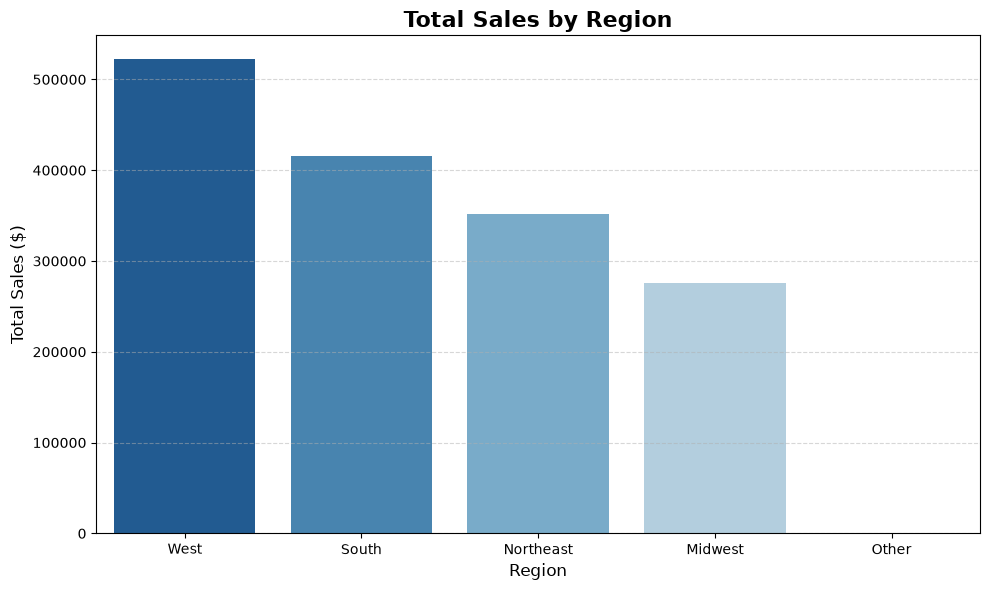

In [5]:
# Group by Region and compute sum of Sales
sales_region = df_clean.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

# Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=sales_region, x='Region', y='Sales', palette='Blues_r')

plt.title('Total Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save the plot in our outputs folder
plt.tight_layout()
plt.savefig('../outputs/sales_by_region.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\akash\AppData\Local\Temp\ipykernel_20876\3934562221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_category, x='Category', y='Sales', palette='Oranges_r')


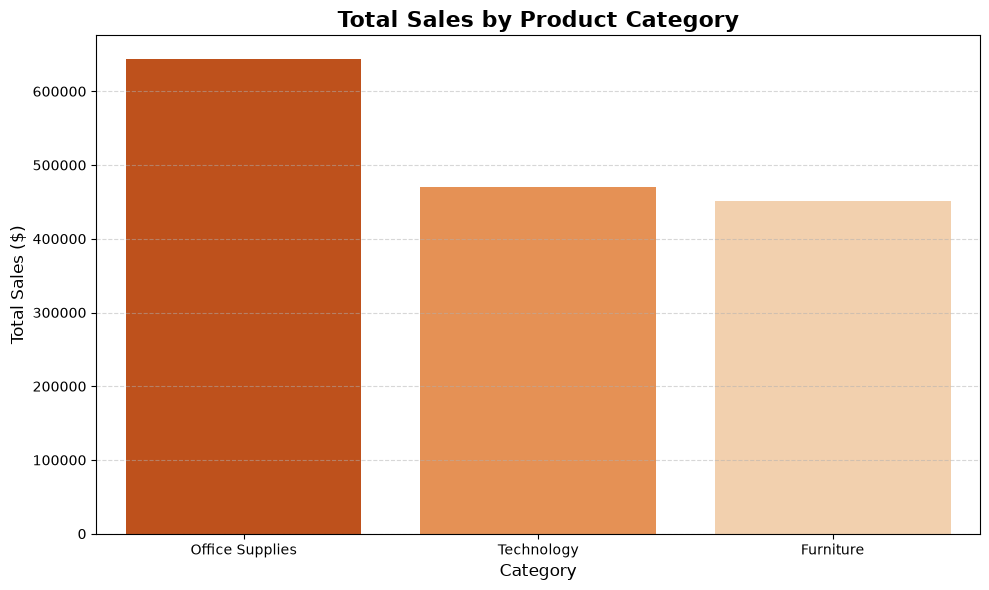

In [6]:
# Group by Category and compute sum of Sales
sales_category = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

# Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=sales_category, x='Category', y='Sales', palette='Oranges_r')

plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save the plot
plt.tight_layout()
plt.savefig('../outputs/sales_by_category.png', dpi=300, bbox_inches='tight')
plt.show()


Monthly Sales Trend (Timeline Analysis)

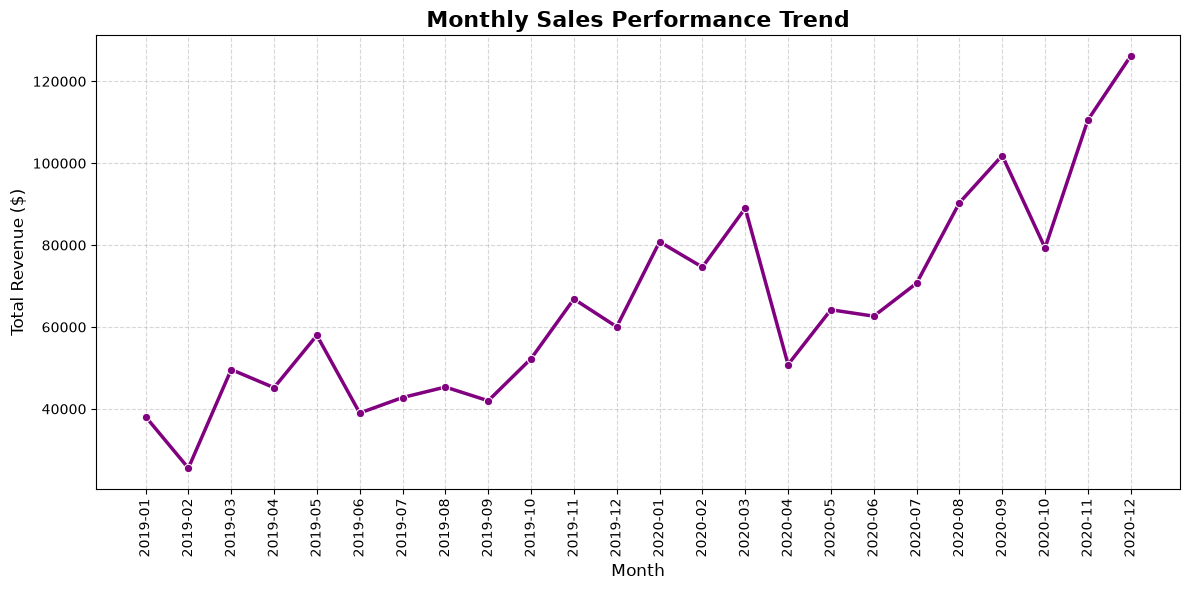

In [7]:
df_trend = df_clean.copy()

# Convert standard order date string to actual datetime for sorting and plotting
df_trend['Order_Date_Dt'] = pd.to_datetime(df_trend['Order_Date'], format='%d-%b-%Y')

# Create a Year-Month column (e.g. 2019-01)
df_trend['YearMonth'] = df_trend['Order_Date_Dt'].dt.to_period('M')

# Group by Month and sum Sales
monthly_sales = df_trend.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth_Str'] = monthly_sales['YearMonth'].astype(str)

# Plot the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='YearMonth_Str', y='Sales', marker='o', color='purple', linewidth=2.5)

plt.title('Monthly Sales Performance Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)

# Save the plot
plt.tight_layout()
plt.savefig('../outputs/monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()


Overall Store Sales Forecast (Prophet Model 1)

C:\Users\akash\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
19:44:01 - cmdstanpy - INFO - Chain [1] start processing
19:44:01 - cmdstanpy - INFO - Chain [1] done processing


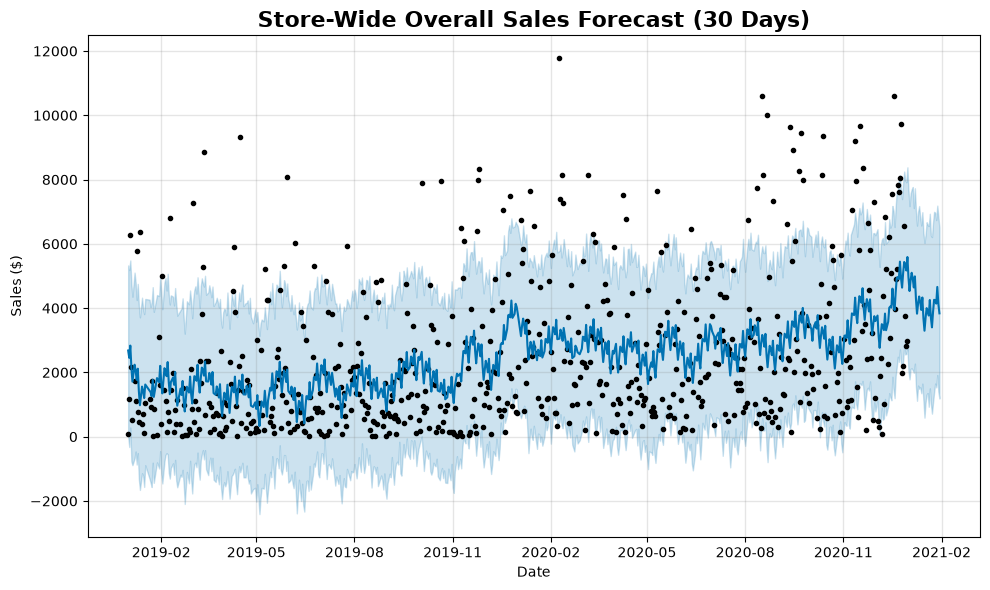

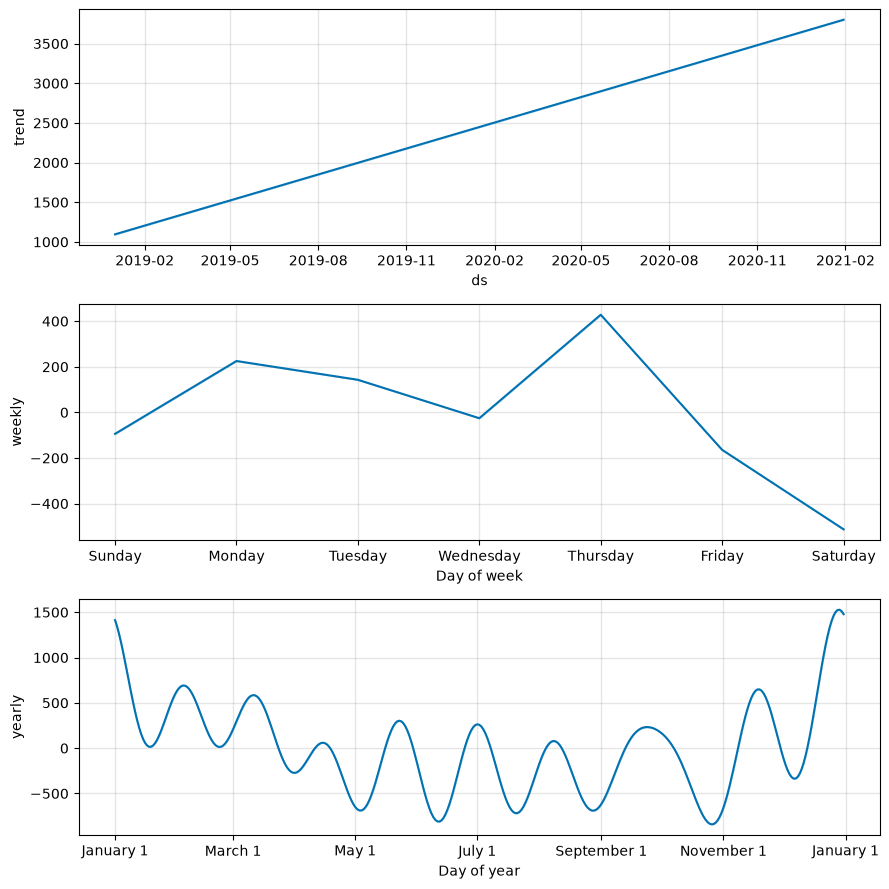

✅ Model 1: Overall Store Sales Forecast completed and saved.


In [8]:
from prophet import Prophet
import logging

# Mute Prophet fit log outputs to keep the notebook clean
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# 1. Prepare data for Overall Store Sales
df_overall = df_clean.copy()
df_overall['Order_Date_Dt'] = pd.to_datetime(df_overall['Order_Date'], format='%d-%b-%Y')

# Group by date and sum Sales
df_overall_prophet = df_overall.groupby('Order_Date_Dt')['Sales'].sum().reset_index()
df_overall_prophet.columns = ['ds', 'y']

# 2. Fit the Prophet Model
model_overall = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_overall.fit(df_overall_prophet)

# 3. Forecast future 30 days
future_overall = model_overall.make_future_dataframe(periods=30)
forecast_overall = model_overall.predict(future_overall)

# 4. Plot & Save Overall Forecast
fig1 = model_overall.plot(forecast_overall)
plt.title('Store-Wide Overall Sales Forecast (30 Days)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/prophet_overall_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Plot & Save Components (Seasonality, Yearly/Weekly Trends)
fig2 = model_overall.plot_components(forecast_overall)
plt.tight_layout()
plt.savefig('../outputs/prophet_components.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Model 1: Overall Store Sales Forecast completed and saved.")


West Region - Technology Sales Forecast (Prophet Model 2)

19:44:28 - cmdstanpy - INFO - Chain [1] start processing
19:44:28 - cmdstanpy - INFO - Chain [1] done processing


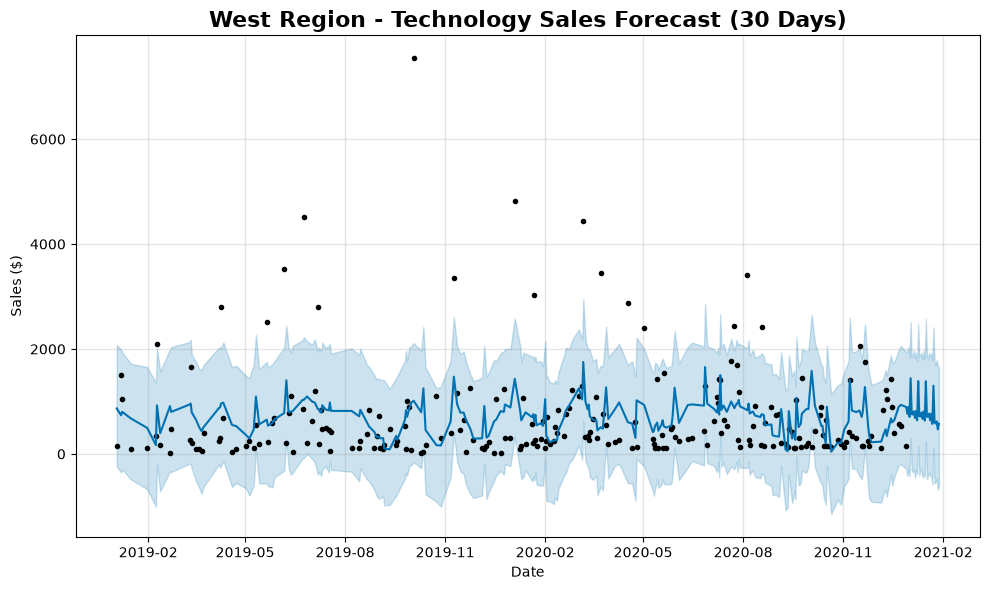

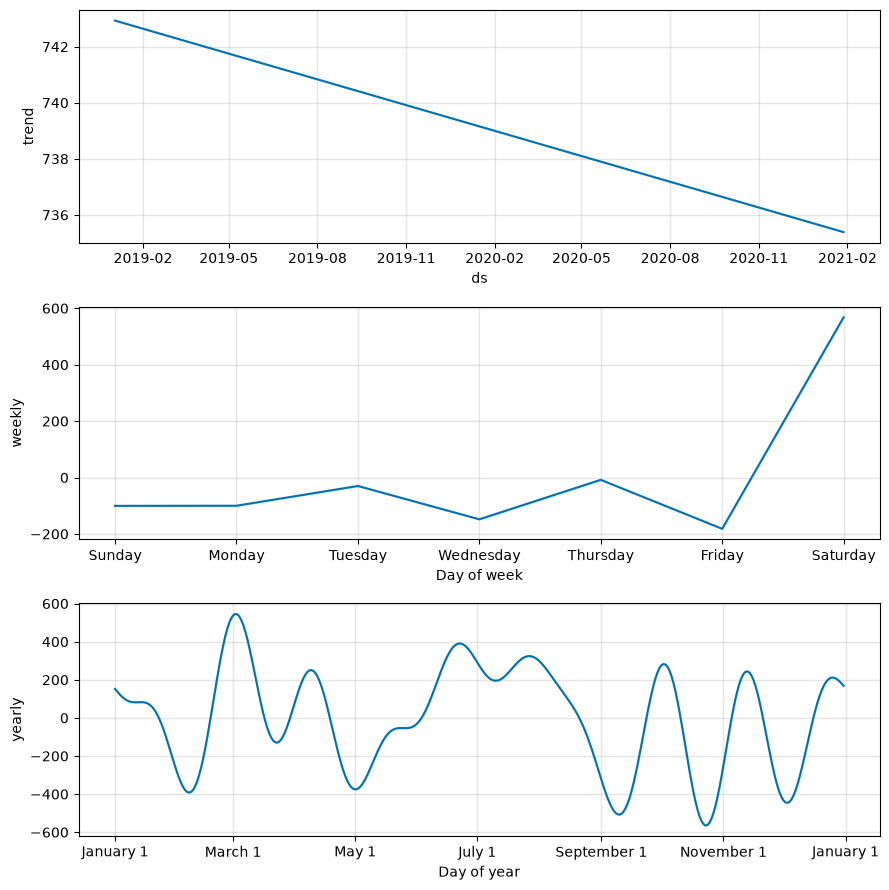

✅ Model 2: West/Technology Sales Forecast completed and saved.


In [9]:
# 1. Filter and Prepare Data for West Region / Technology Segment
df_west_tech = df_clean[(df_clean['Region'] == 'West') & (df_clean['Category'] == 'Technology')].copy()
df_west_tech['Order_Date_Dt'] = pd.to_datetime(df_west_tech['Order_Date'], format='%d-%b-%Y')

# Group by date and sum Sales
df_wt_prophet = df_west_tech.groupby('Order_Date_Dt')['Sales'].sum().reset_index()
df_wt_prophet.columns = ['ds', 'y']

# 2. Fit the Prophet Model
model_wt = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_wt.fit(df_wt_prophet)

# 3. Forecast future 30 days
future_wt = model_wt.make_future_dataframe(periods=30)
forecast_wt = model_wt.predict(future_wt)

# 4. Plot & Save West/Tech Forecast
fig3 = model_wt.plot(forecast_wt)
plt.title('West Region - Technology Sales Forecast (30 Days)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/forecast_west_technology.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Plot & Save West/Tech Components
fig4 = model_wt.plot_components(forecast_wt)
plt.tight_layout()
plt.savefig('../outputs/prophet_components_west_tech.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Model 2: West/Technology Sales Forecast completed and saved.")


Inventory & Stockout Calculations

In [10]:
# 1. Calculate historical daily demand per product
daily_demand = (
    df_clean.groupby(['Product ID', 'Order_Date'])['Quantity']
    .sum()
    .reset_index()
    .rename(columns={'Order_Date': 'ds', 'Quantity': 'demand'})
)

# 2. Compute average daily demand for each product
avg_demand = (
    daily_demand.groupby('Product ID')['demand']
    .mean()
    .reset_index()
    .rename(columns={'demand': 'avg_daily_demand'})
)

# 3. Get unique product inventory rules
stock_cols = ['Product ID', 'Current_Stock', 'Reorder_Level', 'Lead_Time_Days']
stock_info = df_clean[stock_cols].drop_duplicates('Product ID')

# 4. Merge inventory metrics with demand forecasting parameters
inv = stock_info.merge(avg_demand, on='Product ID', how='left')
inv['avg_daily_demand'] = inv['avg_daily_demand'].fillna(0.0)

# 5. Estimate days until stockout
inv['days_to_zero'] = np.where(
    inv['avg_daily_demand'] > 0,
    inv['Current_Stock'] / inv['avg_daily_demand'],
    np.inf
)

# 6. Predict the actual calendar date of stockout
today = pd.Timestamp.today().normalize()
stockout_dates = []
for idx, row in inv.iterrows():
    days = row['days_to_zero']
    if np.isfinite(days) and days >= 0:
        stockout_dates.append((today + pd.to_timedelta(days, unit='D')).strftime('%Y-%m-%d'))
    else:
        stockout_dates.append('No Stockout')
inv['predicted_stockout_date'] = stockout_dates

# 7. Flag high-risk products (Current stock <= Reorder point OR stock runs out before supplier delivery + buffer)
alert_buffer_days = 7
inv['stockout_risk'] = np.where(
    (inv['Current_Stock'] <= inv['Reorder_Level']) |
    (
        np.isfinite(inv['days_to_zero']) &
        (inv['days_to_zero'] <= (inv['Lead_Time_Days'] + alert_buffer_days))
    ),
    1, 0
)

# Filter for active stockout alerts
stockout_alerts = inv[inv['stockout_risk'] == 1].copy()

print(f"✅ Calculated stock risk. Total products analyzed: {len(inv)}")
print(f"⚠️ Products at immediate stockout risk: {len(stockout_alerts)}")
display(stockout_alerts.head())


✅ Calculated stock risk. Total products analyzed: 1755
⚠️ Products at immediate stockout risk: 27


,Product ID,Current_Stock,Reorder_Level,Lead_Time_Days,avg_daily_demand,days_to_zero,predicted_stockout_date,stockout_risk
6,FUR-TA-10000617,70,23,8,4.666667,15.000000,2026-07-12,1
110,OFF-ST-10004340,64,21,8,4.750000,13.473684,2026-07-10,1
149,OFF-ST-10000036,54,18,8,3.750000,14.400000,2026-07-11,1
527,OFF-LA-10002195,53,17,9,5.750000,9.217391,2026-07-06,1
546,OFF-PA-10003591,144,48,9,9.000000,16.000000,2026-07-13,1


Saving Inventory Calculations

In [11]:
# Save alerts and full inventory status to outputs directory
stockout_alerts.to_csv('../outputs/model1_stockout_alerts.csv', index=False)
inv.to_csv('../outputs/model1_inventory_summary.csv', index=False)

print("✅ Saved inventory outputs to the outputs/ directory.")


✅ Saved inventory outputs to the outputs/ directory.


Visualizing Inventory Risk (Scatter Plot)

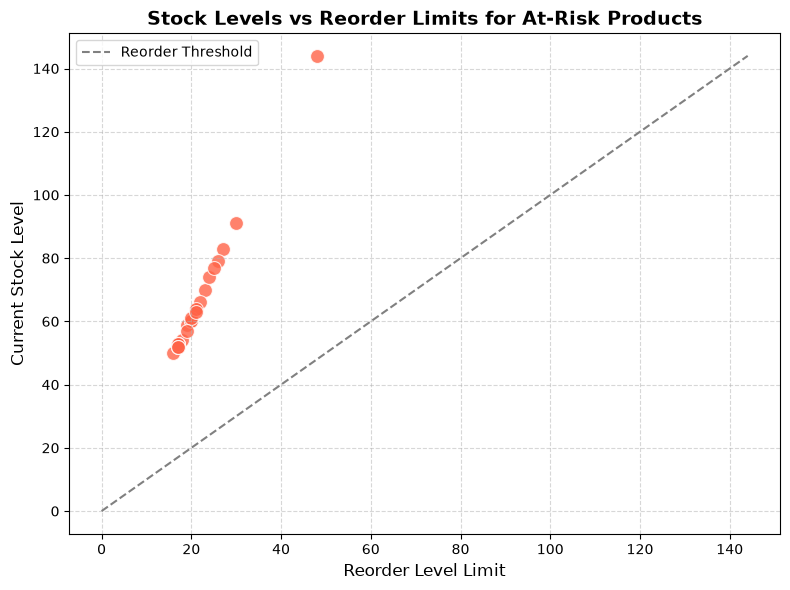

In [12]:
plt.figure(figsize=(8, 6))

# Filter for products flagged with stockout risk
risk_df = inv[inv['stockout_risk'] == 1]

# Scatter plot
sns.scatterplot(data=risk_df, x='Reorder_Level', y='Current_Stock', color='tomato', s=100, alpha=0.8)

# Diagonal threshold line where Stock = Reorder Point
max_val = max(risk_df['Reorder_Level'].max(), risk_df['Current_Stock'].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='Reorder Threshold')

plt.xlabel('Reorder Level Limit', fontsize=12)
plt.ylabel('Current Stock Level', fontsize=12)
plt.title('Stock Levels vs Reorder Limits for At-Risk Products', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Save the plot
plt.tight_layout()
plt.savefig('../outputs/current_stock_vs_reorder_level.png', dpi=300)
plt.show()


Returns & Quality Metrics Analysis

In [13]:
# Reload raw data to include the original 'Returns' flag column
df_returns = df.copy()

# 1. Create a binary return column (1 if returned, 0 if not)
# We assume returns are values > 0 or not NaN in the original dataset
df_returns['is_return'] = df_returns['Returns'].fillna(0).apply(lambda x: 1 if x > 0 else 0)

# 2. Return Rate by Product
product_returns = (
    df_returns.groupby('Product ID')
    .agg(
        total_orders=('Order ID', 'nunique'),
        total_returns=('is_return', 'sum')
    )
    .reset_index()
)
product_returns['return_rate'] = product_returns['total_returns'] / product_returns['total_orders']

# 3. Return Rate by City
city_returns = (
    df_returns.groupby('City')
    .agg(
        total_orders=('Order ID', 'nunique'),
        total_returns=('is_return', 'sum')
    )
    .reset_index()
)
city_returns['return_rate'] = city_returns['total_returns'] / city_returns['total_orders']

# 4. Return Rate by Category over Time (Monthly Trend)
df_returns['Order_Date_Dt'] = pd.to_datetime(df_returns['Order Date'], format='mixed', errors='coerce')
df_returns['YearMonth'] = df_returns['Order_Date_Dt'].dt.to_period('M').dt.to_timestamp()

category_returns = (
    df_returns.groupby(['YearMonth', 'Category'])
    .agg(
        total_orders=('Order ID', 'nunique'),
        total_returns=('is_return', 'sum')
    )
    .reset_index()
)
category_returns['return_rate'] = category_returns['total_returns'] / category_returns['total_orders']

# Save return rate datasets for Power BI
product_returns.to_csv('../outputs/model2_product_return_rates.csv', index=False)
city_returns.to_csv('../outputs/model2_city_return_rates.csv', index=False)
category_returns.to_csv('../outputs/model2_category_return_trend.csv', index=False)

print("✅ Return rates by product, city, and category trend saved to the outputs/ directory.")
display(category_returns.head())


✅ Return rates by product, city, and category trend saved to the outputs/ directory.


,YearMonth,Category,total_orders,total_returns,return_rate
0,2019-01-01,Furniture,27,0,0.0
1,2019-01-01,Office Supplies,56,0,0.0
2,2019-01-01,Technology,26,0,0.0
3,2019-02-01,Furniture,27,0,0.0
4,2019-02-01,Office Supplies,49,0,0.0


Product Profitability Analysis

In [14]:
# 1. Aggregate metrics per product
prod_profit = (
    df_clean.groupby(['Product ID', 'Product Name'])
    .agg(
        total_sales=('Sales', 'sum'),
        total_profit=('Profit', 'sum'),
        total_quantity=('Quantity', 'sum')
    )
    .reset_index()
)

# 2. Calculate profit margin (Profit / Sales)
prod_profit['profit_margin'] = prod_profit['total_profit'] / prod_profit['total_sales']

# 3. Sort by total sales (descending) for overall profitability view
prod_profit = prod_profit.sort_values('total_sales', ascending=False).reset_index(drop=True)

print(f"✅ Total unique products analyzed: {len(prod_profit)}")
display(prod_profit.head(10))


✅ Total unique products analyzed: 1783


,Product ID,Product Name,total_sales,total_profit,total_quantity,profit_margin
0,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14334.890,3717.9714,11,0.259365
1,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,14076.824,25199.9280,20,1.790171
2,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,13837.732,6407.8932,31,0.463074
3,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,12890.258,2753.7593,21,0.213631
4,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,12577.108,762.1544,16,0.060599
5,TEC-PH-10001459,Samsung Galaxy Mega 6.3,12370.708,1696.7596,34,0.137159
6,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,12268.902,-1232.5588,16,-0.100462
7,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,11887.562,70.0980,21,0.005897
8,FUR-CH-10001215,Global Troy Executive Leather Low-Back Tilter,10217.894,776.5190,25,0.075996
9,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,9756.524,-508.3960,16,-0.052108


Segment Products into Tiers
Create a new cell. This segments products into Best Sellers, Loss Makers, and High Revenue but Low Margin categories:

In [16]:
# Best Sellers: Top 10% of products by total sales
sales_threshold = prod_profit['total_sales'].quantile(0.90)
best_sellers = prod_profit[prod_profit['total_sales'] >= sales_threshold].copy()

# Loss Makers: Products with negative total profit
loss_makers = prod_profit[prod_profit['total_profit'] < 0].copy()

# High Revenue, Low Margin: Top 25% by sales, but profit margin below 10%
rev_threshold = prod_profit['total_sales'].quantile(0.75)
high_rev_low_margin = prod_profit[
    (prod_profit['total_sales'] >= rev_threshold) &
    (prod_profit['profit_margin'] < 0.10)
].copy()

print(f"✅ Best Sellers (Top 10% by Revenue):        {len(best_sellers)} products")
print(f"⚠️  Loss Makers (Negative Profit):           {len(loss_makers)} products")
print(f"🔍 High Revenue, Low Margin (<10% margin):  {len(high_rev_low_margin)} products")


✅ Best Sellers (Top 10% by Revenue):        179 products
⚠️  Loss Makers (Negative Profit):           314 products
🔍 High Revenue, Low Margin (<10% margin):  233 products


Save Profitability Outputs
Create a new cell to save all four profitability datasets:

In [17]:
# Save all profitability tables to the outputs folder
prod_profit.to_csv('../outputs/model3_product_profitability.csv', index=False)
best_sellers.to_csv('../outputs/model3_best_sellers.csv', index=False)
loss_makers.to_csv('../outputs/model3_loss_makers.csv', index=False)
high_rev_low_margin.to_csv('../outputs/model3_high_rev_low_margin.csv', index=False)

print("✅ Saved all product profitability outputs to outputs/ directory.")


✅ Saved all product profitability outputs to outputs/ directory.


**Visualize Profit vs Revenue Scatter Plot**
Create a new cell to plot a scatter chart showing every product's position in the Sales vs Profit Margin space — the chart makes it very easy to spot which products are most valuable vs which are dragging profits down:

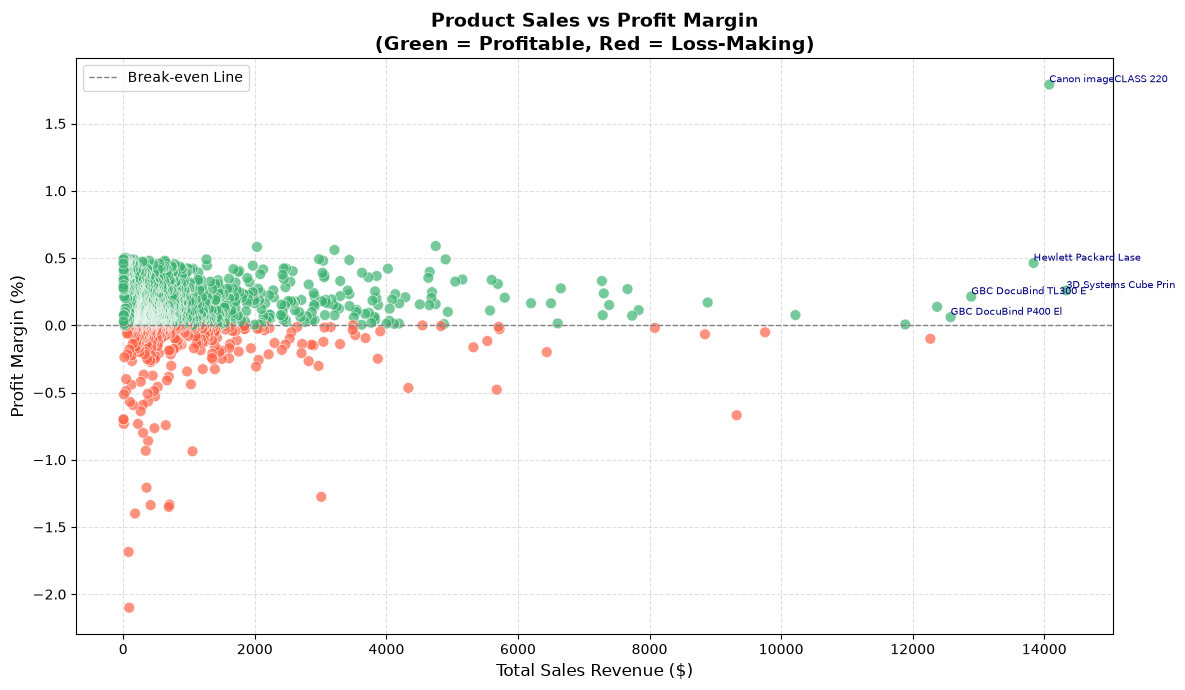

✅ Saved product profitability scatter plot.


In [18]:
plt.figure(figsize=(12, 7))

# Color based on profit: green for positive, red for negative
colors = prod_profit['total_profit'].apply(lambda x: 'mediumseagreen' if x >= 0 else 'tomato')

plt.scatter(
    prod_profit['total_sales'],
    prod_profit['profit_margin'],
    c=colors,
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)

# Mark the zero-margin line
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, label='Break-even Line')

# Annotate the top 5 best sellers
top5 = prod_profit.nlargest(5, 'total_sales')
for _, row in top5.iterrows():
    plt.annotate(
        row['Product Name'][:20],
        xy=(row['total_sales'], row['profit_margin']),
        fontsize=7,
        ha='left',
        va='bottom',
        color='navy'
    )

plt.xlabel('Total Sales Revenue ($)', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.title('Product Sales vs Profit Margin\n(Green = Profitable, Red = Loss-Making)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/product_profit_vs_sales.png', dpi=300)
plt.show()

print("✅ Saved product profitability scatter plot.")


**Top 10 Best Sellers Bar Chart**
Create one final cell to visualize the top 10 products by revenue with their profit margin overlaid:

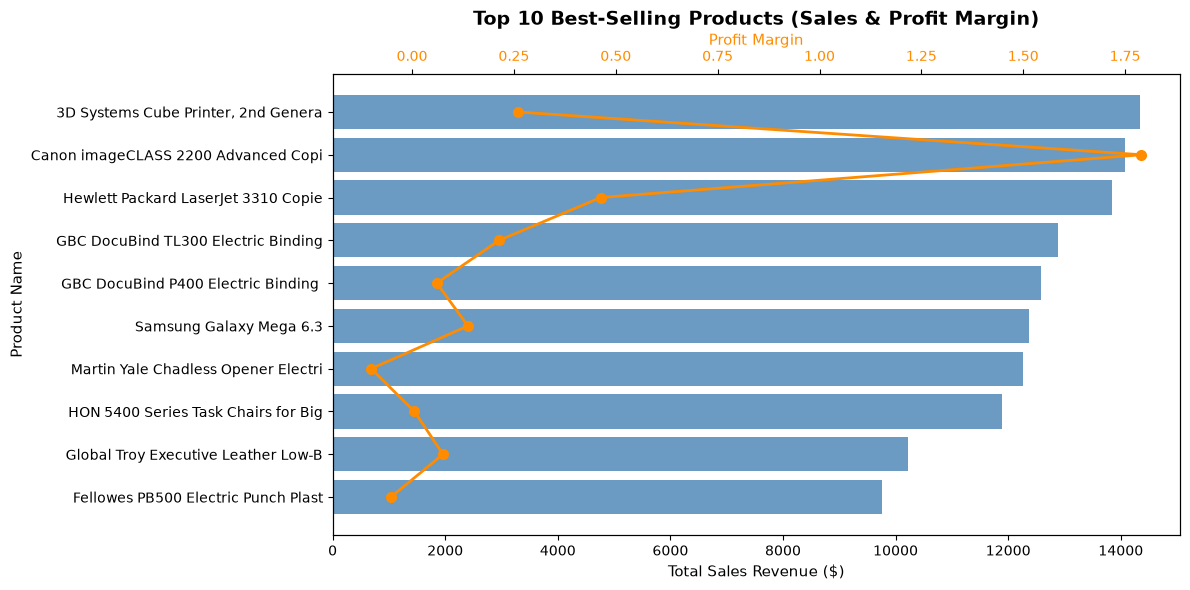

✅ Saved Top 10 Best Sellers chart.


In [19]:
top10 = prod_profit.nlargest(10, 'total_sales').sort_values('total_sales')

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for sales
bars = ax1.barh(top10['Product Name'].str[:35], top10['total_sales'], color='steelblue', alpha=0.8)
ax1.set_xlabel('Total Sales Revenue ($)', fontsize=11)
ax1.set_ylabel('Product Name', fontsize=11)
ax1.set_title('Top 10 Best-Selling Products (Sales & Profit Margin)', fontsize=14, fontweight='bold')

# Overlay line for profit margin
ax2 = ax1.twiny()
ax2.plot(top10['profit_margin'], top10['Product Name'].str[:35], 'o-', color='darkorange', linewidth=2, markersize=7)
ax2.set_xlabel('Profit Margin', fontsize=11, color='darkorange')
ax2.tick_params(axis='x', labelcolor='darkorange')

plt.tight_layout()
plt.savefig('../outputs/top10_best_sellers.png', dpi=300)
plt.show()

print("✅ Saved Top 10 Best Sellers chart.")


In [20]:
# ── PHASE 2: EDA ──────────────────────────────────────────────────
df_clean.to_csv('outputs/clean_sales_data.csv', index=False)

# ── PHASE 3: Forecasting ──────────────────────────────────────────
fig1 = model_overall.plot(forecast_overall)
plt.title('Store-Wide Overall Sales Forecast (30 Days)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/prophet_overall_forecast.png', dpi=300, bbox_inches='tight')
plt.close()

fig2 = model_overall.plot_components(forecast_overall)
plt.tight_layout()
plt.savefig('outputs/prophet_components.png', dpi=300, bbox_inches='tight')
plt.close()

fig3 = model_wt.plot(forecast_wt)
plt.title('West Region - Technology Sales Forecast (30 Days)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/forecast_west_technology.png', dpi=300, bbox_inches='tight')
plt.close()

fig4 = model_wt.plot_components(forecast_wt)
plt.tight_layout()
plt.savefig('outputs/prophet_components_west_tech.png', dpi=300, bbox_inches='tight')
plt.close()

# ── PHASE 4: Inventory ────────────────────────────────────────────
stockout_alerts.to_csv('outputs/model1_stockout_alerts.csv', index=False)
inv.to_csv('outputs/model1_inventory_summary.csv', index=False)

product_returns.to_csv('outputs/model2_product_return_rates.csv', index=False)
city_returns.to_csv('outputs/model2_city_return_rates.csv', index=False)
category_returns.to_csv('outputs/model2_category_return_trend.csv', index=False)

# ── PHASE 5: Profitability ────────────────────────────────────────
prod_profit.to_csv('outputs/model3_product_profitability.csv', index=False)
best_sellers.to_csv('outputs/model3_best_sellers.csv', index=False)
loss_makers.to_csv('outputs/model3_loss_makers.csv', index=False)
high_rev_low_margin.to_csv('outputs/model3_high_rev_low_margin.csv', index=False)

print("✅ All files saved successfully to outputs/ folder!")
print("Files saved:")
for f in sorted(os.listdir('outputs')):
    print(f"  ✓ {f}")


✅ All files saved successfully to outputs/ folder!
Files saved:
  ✓ clean_sales_data.csv
  ✓ forecast_west_technology.png
  ✓ model1_inventory_summary.csv
  ✓ model1_stockout_alerts.csv
  ✓ model2_category_return_trend.csv
  ✓ model2_city_return_rates.csv
  ✓ model2_product_return_rates.csv
  ✓ model3_best_sellers.csv
  ✓ model3_high_rev_low_margin.csv
  ✓ model3_loss_makers.csv
  ✓ model3_product_profitability.csv
  ✓ prophet_components.png
  ✓ prophet_components_west_tech.png
  ✓ prophet_overall_forecast.png
